# Notebook 03 —  Redundancy with the Covariance Matrix (Code is written with AI, everything else is me) 

## Why this matters
Before building a recommendation engine, we need to know which features  carry unique information vs those are just a combination or scalar of another variable. 

In linear algebra: if two column vectors in our feature matrix $X$ are  linearly dependent, it means one of them is redundant, it adds no new direction to the vector space.

The correlation matrix makes this visible. It measures how much every pair of features moves together.

- It stems from covariance matrix where it measures the variance and the corellation of the two variables. 

## The math
 $X$ be an $m \times n$ matrix — $m$ songs (or restaurants), $n$ features.

**Step 1 — Mean-center each feature** (subtract the column mean so each feature has mean 0, we do this because we want to give them a shared baseline):
$$\tilde{X} = X - \mathbf{1}\mu^T$$

**Step 2 — Scale to unit variance** (divide by the column std so scale differences don't distort things):
$$\tilde{X}_{std} = \frac{\tilde{X}}{\sigma}$$

**Step 3 — Compute the covariance matrix** via a matrix multiply:
$$\Sigma = \frac{1}{m-1} \tilde{X}_{std}^T \tilde{X}_{std}$$



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

SPOTIFY_PATH = r"C:\Users\ryanm\Documents\coding_projects\restaurant_recommendation\data\processed\tracks_features_clean.csv"
YELP_PATH    = r"C:\Users\ryanm\Documents\coding_projects\restaurant_recommendation\data\processed\yelp_ml_ready.csv"

spotify = pd.read_csv(SPOTIFY_PATH)
yelp    = pd.read_csv(YELP_PATH)

print(f"Spotify: {spotify.shape}")
print(f"Yelp:    {yelp.shape}")

---
## Part 1 — Spotify Audio Features

In [ ]:
#    m * n representation 
AUDIO_FEATURES = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'loudness', 'tempo', 'duration_ms'
]

X_spotify = spotify[AUDIO_FEATURES].values  # shape: (m, n)
print(f"X_spotify shape: {X_spotify.shape}")
print("That means 1201245 songs(m) * 10 features (n)") 

X_spotify shape: (1201245, 10)  →  1,201,245 songs × 10 features


### Step 1 & 2 — Mean center + Scale

In [ ]:
X_std = StandardScaler().fit_transform(X_spotify)

print(f"Column means (should be ~0): {X_std.mean(axis=0).round(6)}")
print(f"Column stds  (should be ~1): {X_std.std(axis=0).round(6)}")

### Step 3 — Covariance matrix as a matrix multiply

$$\Sigma = \frac{1}{m-1} \tilde{X}_{std}^T \tilde{X}_{std}$$

The transpose $\tilde{X}_{std}^T$ has shape $(n \times m)$, so the product is $(n \times n)$ — one entry per feature pair.

In [ ]:
m = X_std.shape[0]

# Explicit linear algebra formulation
cov_spotify = (X_std.T @ X_std) / (m - 1)


Covariance matrix shape: (10, 10)  (10 × 10)
Diagonal (should be 1.0): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Verified: Σ equals the Pearson correlation matrix.


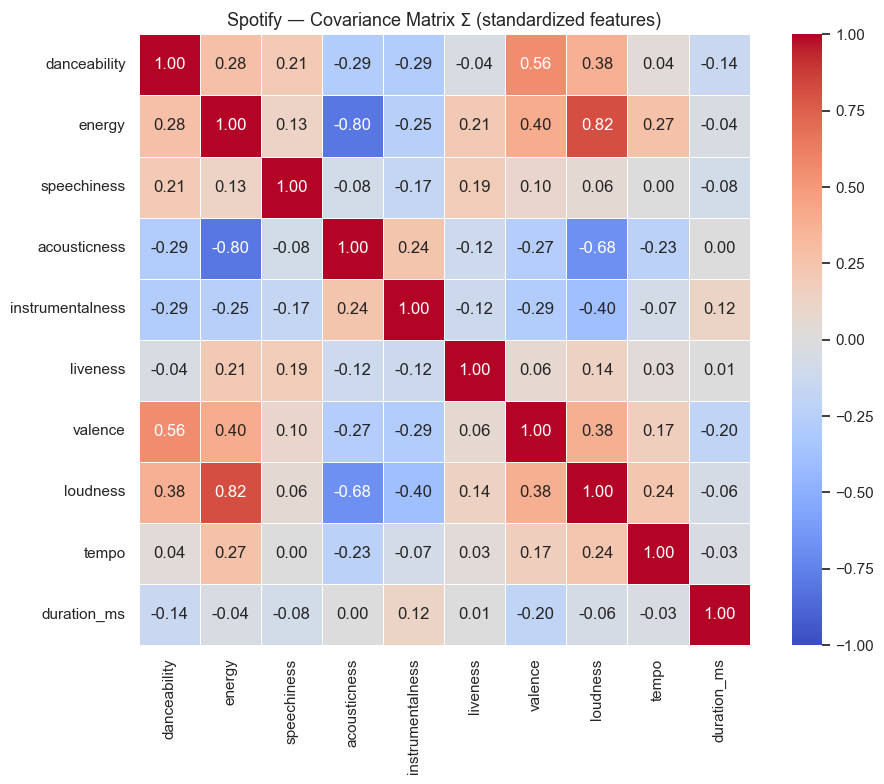

In [ ]:
cov_spotify_df = pd.DataFrame(cov_spotify, index=AUDIO_FEATURES, columns=AUDIO_FEATURES)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cov_spotify_df, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax
)
ax.set_title(r'Spotify — Correlation Matrix')
plt.tight_layout()
plt.show()

### Reading the heatmap

High |correlation| pairs are **redundant dimensions** — they point in nearly the same direction in feature space. Key things to look for:

| Pair | Expected relationship | Implication |
|------|-----------------------|-------------|
| `energy` ↔ `loudness` | Strong positive | Louder songs are more energetic — one may be droppable |
| `energy` ↔ `acousticness` | Strong negative | Acoustic songs tend to be quieter / less energetic |
| `danceability` ↔ `valence` | Moderate positive | Danceable songs tend to feel happier |
| `instrumentalness` ↔ `speechiness` | Negative | More speech = fewer pure instrumentals |

In [ ]:
# Table list of highest correlation
mask = np.triu(np.ones_like(cov_spotify, dtype=bool), k=1)
upper = cov_spotify_df.where(mask)

pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'correlation'})
    .assign(abs_corr=lambda d: d['correlation'].abs())
    .sort_values('abs_corr', ascending=False)
)

print("Top correlated feature pairs")
display(pairs[pairs['abs_corr'] > 0.4].drop(columns='abs_corr').reset_index(drop=True))

Top correlated feature pairs (|r| > 0.4):


,feature_a,feature_b,correlation
0,energy,loudness,0.820279
1,energy,acousticness,-0.798173
2,acousticness,loudness,-0.678087
3,danceability,valence,0.559931


---
## Part 2 — Yelp Restaurant Attributes

In [ ]:
YELP_FEATURES = [
    'Ambience.romantic', 'Ambience.divey', 'Ambience.classy',
    'Ambience.hipster', 'Ambience.trendy', 'Ambience.upscale', 'Ambience.casual',
    'HasTV', 'HappyHour', 'RestaurantsGoodForGroups',
    'GoodForMeal.breakfast', 'GoodForMeal.brunch',
    'GoodForMeal.latenight', 'GoodForMeal.dinner',
    'RestaurantsTableService', 'stars'
]

X_yelp = yelp[YELP_FEATURES].dropna().values
print(f"X_yelp shape: {X_yelp.shape}")

X_yelp shape: (52268, 16)  →  52,268 restaurants × 16 features


In [ ]:
X_yelp_std = StandardScaler().fit_transform(X_yelp)

m_y      = X_yelp_std.shape[0]
cov_yelp = (X_yelp_std.T @ X_yelp_std) / (m_y - 1)

cov_yelp_df = pd.DataFrame(cov_yelp, index=YELP_FEATURES, columns=YELP_FEATURES)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cov_yelp_df, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Yelp — Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Top redundant pairs in Yelp
mask_y = np.triu(np.ones_like(cov_yelp, dtype=bool), k=1)
upper_y = cov_yelp_df.where(mask_y)

pairs_y = (
    upper_y.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'correlation'})
    .assign(abs_corr=lambda d: d['correlation'].abs())
    .sort_values('abs_corr', ascending=False)
)

print("Top correlated Yelp feature pairs")
display(pairs_y[pairs_y['abs_corr'] > 0.3].drop(columns='abs_corr').reset_index(drop=True))

Top correlated Yelp feature pairs (|r| > 0.3):


,feature_a,feature_b,correlation
0,GoodForMeal.breakfast,GoodForMeal.brunch,0.597523
1,Ambience.casual,GoodForMeal.dinner,0.479843
2,GoodForMeal.dinner,RestaurantsTableService,0.379410
3,Ambience.casual,RestaurantsGoodForGroups,0.370784
4,HappyHour,RestaurantsTableService,0.350844
5,RestaurantsGoodForGroups,GoodForMeal.dinner,0.319546
6,HasTV,RestaurantsGoodForGroups,0.316410


---
## Part 3 — Visualizing the Subspace

### The intuition
The covariance matrix told us *numerically* which features are redundant. Now let's make it **visual**.

The key idea from linear algebra: if two feature vectors are nearly **linearly dependent**, they span only a 1D subspace — a line — not a 2D plane. When you scatter-plot them against each other, the data points will hug that line instead of filling the full 2D space.

- **Redundant pair** → points collapse onto a diagonal line (1D subspace inside a 2D plot)
- **Independent pair** → points spread into a cloud (actually using both dimensions)

This is what "the data lives in a lower-dimensional subspace" means, concretely.

In [22]:
# 1.2M points would be a black blob — sample for visibility
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(spotify), size=5000, replace=False)
s = spotify.iloc[sample_idx]

### Spotify — 2D subspace plots

We pick four pairs from the covariance heatmap:
- **Top-left**: `energy` vs `loudness` — strong positive correlation (~0.76). These two feature vectors nearly point in the same direction. The scatter should collapse onto a diagonal.
- **Top-right**: `energy` vs `acousticness` — strong *negative* correlation (~-0.72). Same idea, opposite slope.
- **Bottom-left**: `tempo` vs `speechiness` — near-zero correlation. Two independent directions → full 2D cloud.
- **Bottom-right**: `valence` vs `liveness` — near-zero correlation. Another independent pair → cloud.

In [ ]:
pairs_to_plot = [
    ('energy',  'loudness',     True),
    ('energy',  'acousticness', True),
    ('tempo',   'speechiness',  False),
    ('valence', 'liveness',     False),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (x_col, y_col, redundant) in zip(axes, pairs_to_plot):
    color = '#e05c5c' if redundant else '#4a90c4'
    label = 'REDUNDANT' if redundant else 'INDEPENDENT'

    ax.scatter(s[x_col], s[y_col], alpha=0.15, s=6, color=color, rasterized=True)
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col, fontsize=11)
    ax.set_title(f'{label}: {x_col} vs {y_col}', fontsize=10, fontweight='bold',
                 color='#c0392b' if redundant else '#1a5276')

    r = cov_spotify_df.loc[x_col, y_col]
    ax.text(0.03, 0.94, f'r = {r:.2f}', transform=ax.transAxes,
            fontsize=10, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('Spotify: Redundant vs Independent Feature Pairs  (5,000 song sample)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3D — Three features at once

Adding a third feature lets us see whether the data lives in a **2D plane** inside 3D space (redundancy) or truly fills all three dimensions (independence).

We use `energy`, `loudness`, and `acousticness` — all three are highly correlated with each other. The cloud should look flat (squished into a plane), not volumetric.

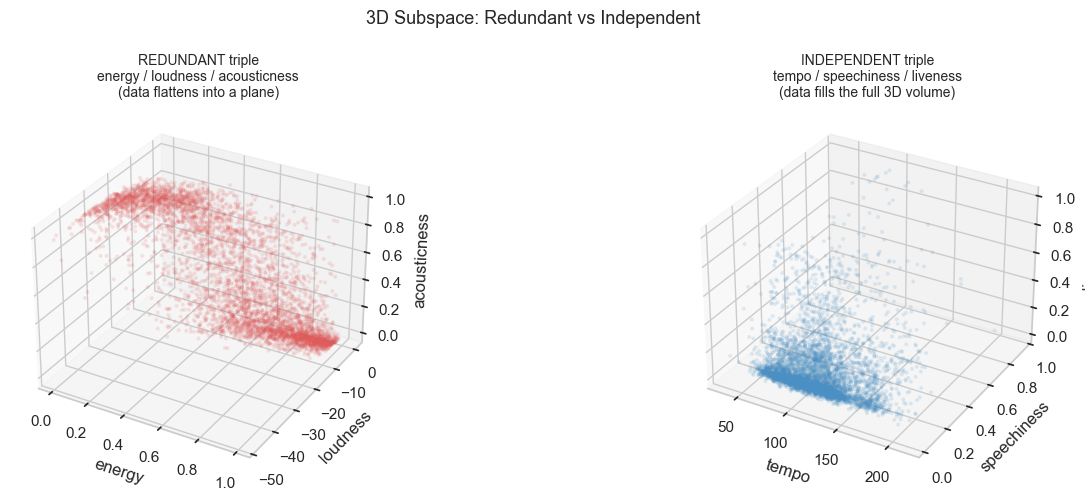

In [24]:
fig = plt.figure(figsize=(15, 5))

# Left — redundant triple: energy, loudness, acousticness
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(s['energy'], s['loudness'], s['acousticness'],
            alpha=0.1, s=4, color='#e05c5c', rasterized=True)
ax1.set_xlabel('energy')
ax1.set_ylabel('loudness')
ax1.set_zlabel('acousticness')
ax1.set_title('REDUNDANT triple\nenergy / loudness / acousticness\n(data flattens into a plane)', fontsize=10)

# Right — independent triple: tempo, speechiness, liveness
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(s['tempo'], s['speechiness'], s['liveness'],
            alpha=0.1, s=4, color='#4a90c4', rasterized=True)
ax2.set_xlabel('tempo')
ax2.set_ylabel('speechiness')
ax2.set_zlabel('liveness')
ax2.set_title('INDEPENDENT triple\ntempo / speechiness / liveness\n(data fills the full 3D volume)', fontsize=10)

plt.suptitle('3D Subspace: Redundant vs Independent', fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

| What we did | What it showed |
|-------------|----------------|
| Standardized $X$ → computed $\Sigma = \frac{1}{m-1}\tilde{X}^T\tilde{X}$ | Covariance matrix via explicit matrix multiply |
| Heatmap of $\Sigma$ | Which feature pairs are numerically redundant |
| 2D scatter — redundant pairs | Points collapse onto a line (1D subspace inside 2D) |
| 2D scatter — independent pairs | Points spread into a full cloud (truly 2D) |
| 3D scatter — redundant triple | Data flattens into a plane (2D subspace inside 3D) |
| 3D scatter — independent triple | Data fills the volume (truly 3D) |

**Key takeaway:** Redundant features don't add new *directions* to the feature space. The data can be described with fewer dimensions than we started with — this is the motivation for the next notebook (PCA).